## Fase 2 - entrenamiento final y evaluacion sobre test (ResNet50, disease)

Tras la validacion cruzada (fase 1, que estima el rendimiento esperado), se entrena un unico modelo final usando la particion train/val/test original: se entrena con **train**, se monitoriza el entrenamiento con **val** (early stopping y reduccion de LR) y se evalua el rendimiento una sola vez sobre **test**.

In [1]:
import os
import json
import time
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, cohen_kappa_score,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

train_csv  = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/train_onehot.csv"
val_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/val_onehot.csv"
test_csv   = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/test_onehot.csv"
images_dir = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 7
TASK_NAME   = "disease"
CUT_LAYER   = 39
class_cols  = ["dx_akiec", "dx_bcc", "dx_bkl", "dx_df", "dx_mel", "dx_nv", "dx_vasc"]
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

WARMUP_EPOCHS, FT_EPOCHS = 30, 30
WARMUP_LR, FT_LR = 1e-3, 1e-5

EXP_DIR = Path("ResNet_STL") / f"exp_{dt.datetime.now():%Y-%m-%d_%H-%M}_disease_FASE2_final"
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento fase 2 en: {EXP_DIR}")

2026-06-22 22:47:08.268465: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


Experimento fase 2 en: ResNet_STL/exp_2026-06-22_22-47_disease_FASE2_final


In [2]:
# Particion original train / val / test
df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)
for df in (df_train, df_val, df_test):
    df["filepath"] = df["image_id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

y_train = df_train[class_cols].values.astype("float32")
y_val   = df_val[class_cols].values.astype("float32")
y_test  = df_test[class_cols].values.astype("float32")
y_test_int = np.argmax(y_test, axis=1)

print(f"train: {len(df_train)}   val: {len(df_val)}   test: {len(df_test)}")


def load_image(filepath, y, training=False):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.clip_by_value(img, 0.0, 255.0)
    img = tf.keras.applications.resnet.preprocess_input(img)
    return img, y


def make_dataset(filepaths, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, y))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(lambda f, yy: load_image(f, yy, training), num_parallel_calls=15)
    return ds.batch(BATCH_SIZE).prefetch(50)


train_ds = make_dataset(df_train["filepath"].values, y_train, training=True)
val_ds   = make_dataset(df_val["filepath"].values,   y_val,   training=False)
test_ds  = make_dataset(df_test["filepath"].values,  y_test,  training=False)

train: 6008   val: 2003   test: 2003


2026-06-22 22:47:09.301013: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2026-06-22 22:47:09.324069: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:05:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.91GiB deviceMemoryBandwidth: 451.17GiB/s
2026-06-22 22:47:09.324100: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2026-06-22 22:47:09.325520: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-22 22:47:09.326752: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcufft.so.10
2026-06-22 22:47:09.326961: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcurand.so

In [3]:
def build_model():
    base_model = tf.keras.applications.ResNet50(
        include_top=False, weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    )
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_image")
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.Dense(256, activation="relu", name="shared_dense")(x)
    x = tf.keras.layers.Dropout(0.3, name="shared_dropout")(x)
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="head_disease")(x)
    model = tf.keras.Model(inputs, out, name="STL_ResNet50_disease")
    return model, base_model


def unfreeze_from(base_model, cut_layer):
    base_model.trainable = True
    for layer in base_model.layers:
        layer.trainable = False
    for i, layer in enumerate(base_model.layers):
        if i >= cut_layer:
            layer.trainable = True

In [4]:
# Class weights balanceados sobre train
y_train_int = np.argmax(y_train, axis=1)
cw = compute_class_weight(class_weight="balanced",
                          classes=np.arange(NUM_CLASSES), y=y_train_int)
class_weight_dict = {i: float(cw[i]) for i in range(NUM_CLASSES)}
print(f"class weights: {cw.round(3)}")

model, base_model = build_model()

# Fase 1: warmup (solo la cabeza, backbone congelado)
print(f"Warmup (head, LR={WARMUP_LR})")
model.compile(optimizer=tf.keras.optimizers.Adam(WARMUP_LR),
              loss="categorical_crossentropy", metrics=["accuracy"])
cb_warmup = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, min_delta=0.005,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                                         min_lr=1e-7, verbose=1),
]
t0 = time.time()
h1 = model.fit(train_ds, validation_data=val_ds, epochs=WARMUP_EPOCHS,
               class_weight=class_weight_dict, callbacks=cb_warmup, verbose=2)
t_warmup = time.time() - t0

# Fase 2: fine-tuning (backbone descongelado desde CUT_LAYER)
print(f"Fine-tuning (cut_layer={CUT_LAYER}, LR={FT_LR})")
unfreeze_from(base_model, CUT_LAYER)
model.compile(optimizer=tf.keras.optimizers.Adam(FT_LR),
              loss="categorical_crossentropy", metrics=["accuracy"])
cb_ft = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, min_delta=0.005,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                                         min_lr=1e-7, verbose=1),
]
t0 = time.time()
h2 = model.fit(train_ds, validation_data=val_ds, epochs=FT_EPOCHS,
               class_weight=class_weight_dict, callbacks=cb_ft, verbose=2)
t_ft = time.time() - t0

history = {k: list(h1.history.get(k, [])) + list(h2.history.get(k, [])) for k in h1.history}
pd.DataFrame(history).to_csv(EXP_DIR / "history.csv", index=False)
model.save_weights(str(EXP_DIR / "final_weights"), save_format="tf")

class weights: [ 4.379  2.787  1.3   12.439  1.285  0.213 10.097]
Warmup (head, LR=0.001)
Epoch 1/30


2026-06-22 22:47:14.801801: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-22 22:47:15.107861: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7


188/188 - 17s - loss: 1.5965 - accuracy: 0.4742 - val_loss: 1.6840 - val_accuracy: 0.3769
Epoch 2/30
188/188 - 17s - loss: 1.1402 - accuracy: 0.5518 - val_loss: 1.1474 - val_accuracy: 0.5372
Epoch 3/30
188/188 - 17s - loss: 1.0002 - accuracy: 0.5890 - val_loss: 0.9465 - val_accuracy: 0.6370
Epoch 4/30
188/188 - 17s - loss: 0.9089 - accuracy: 0.6157 - val_loss: 0.8735 - val_accuracy: 0.6755
Epoch 5/30
188/188 - 18s - loss: 0.8679 - accuracy: 0.6445 - val_loss: 0.8546 - val_accuracy: 0.6665
Epoch 6/30
188/188 - 17s - loss: 0.8535 - accuracy: 0.6510 - val_loss: 0.8917 - val_accuracy: 0.6331
Epoch 7/30
188/188 - 19s - loss: 0.8107 - accuracy: 0.6536 - val_loss: 0.9204 - val_accuracy: 0.6241
Epoch 8/30

Epoch 00008: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
188/188 - 17s - loss: 0.7617 - accuracy: 0.6693 - val_loss: 1.0537 - val_accuracy: 0.5851
Epoch 9/30
188/188 - 18s - loss: 0.6470 - accuracy: 0.7014 - val_loss: 0.8429 - val_accuracy: 0.6610
Epoch 10/30
188/188 -

              precision    recall  f1-score   support

       akiec     0.5455    0.7273    0.6234        66
         bcc     0.7019    0.7087    0.7053       103
         bkl     0.7124    0.7580    0.7345       219
          df     0.6429    0.3913    0.4865        23
         mel     0.5505    0.7085    0.6196       223
          nv     0.9455    0.8799    0.9115      1341
        vasc     0.8966    0.9286    0.9123        28

    accuracy                         0.8288      2003
   macro avg     0.7136    0.7289    0.7133      2003
weighted avg     0.8462    0.8288    0.8347      2003



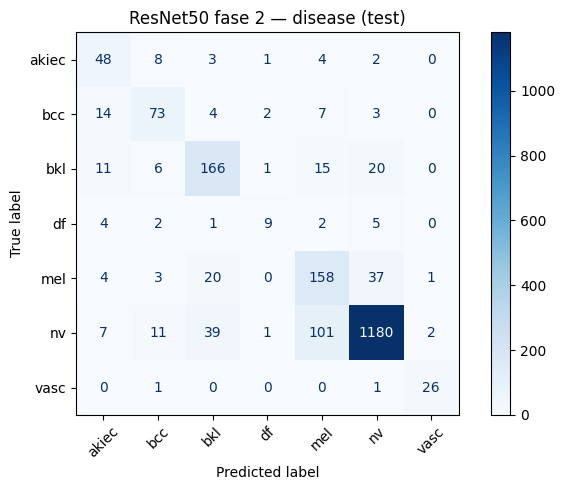


F1 macro test: 0.7133   balanced acc: 0.7289


In [5]:
# Evaluacion unica sobre test
y_pred_proba = model.predict(test_ds, verbose=0)
y_pred_int   = np.argmax(y_pred_proba, axis=1)

metrics = {
    "model":                   "ResNet50",
    "disease_acc":             float((y_test_int == y_pred_int).mean()),
    "disease_balanced_acc":    float(balanced_accuracy_score(y_test_int, y_pred_int)),
    "disease_precision_macro": float(precision_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "disease_recall_macro":    float(recall_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "disease_f1_macro":        float(f1_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "disease_f1_weighted":     float(f1_score(y_test_int, y_pred_int, average="weighted", zero_division=0)),
    "disease_kappa":           float(cohen_kappa_score(y_test_int, y_pred_int)),
    "epochs_warmup":           len(h1.history["loss"]),
    "epochs_ft":               len(h2.history["loss"]),
    "time_train_s":            round(t_warmup + t_ft, 1),
}
try:
    metrics["disease_auc_macro"] = float(roc_auc_score(
        np.eye(NUM_CLASSES)[y_test_int], y_pred_proba, multi_class="ovr", average="macro"))
except Exception:
    metrics["disease_auc_macro"] = float("nan")
metrics["auc_melanoma"] = float(roc_auc_score((y_test_int == 4).astype(int), y_pred_proba[:, 4]))

(EXP_DIR / "metrics_FASE2.json").write_text(json.dumps(metrics, indent=2))
pd.DataFrame([metrics]).to_csv(EXP_DIR / "metrics_FASE2.csv", index=False)

rpt = classification_report(y_test_int, y_pred_int, target_names=class_names, digits=4)
(EXP_DIR / "classification_report_disease.txt").write_text(rpt)
print(rpt)

cm = confusion_matrix(y_test_int, y_pred_int)
np.save(EXP_DIR / "confusion_matrix_disease.npy", cm)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
ax.set_title("ResNet50 fase 2 - disease (test)")
plt.tight_layout(); plt.savefig(EXP_DIR / "confusion_matrix_disease.png", dpi=120); plt.show()

print(f"\nF1 macro test: {metrics['disease_f1_macro']:.4f}   "
      f"balanced acc: {metrics['disease_balanced_acc']:.4f}")

In [6]:
# CSV de predicciones imagen a imagen (entrada del estudio estadistico)
df_pred = pd.DataFrame({
    "image_id":   df_test["image_id"].values,
    "true_label": [class_names[i] for i in y_test_int],
    "pred_label": [class_names[i] for i in y_pred_int],
    "true_idx":   y_test_int,
    "pred_idx":   y_pred_int,
})
for j, c in enumerate(class_names):
    df_pred[f"prob_{c}"] = y_pred_proba[:, j]

out_csv = EXP_DIR / "predictions_STL_ResNet50_disease_FASE2.csv"
df_pred.to_csv(out_csv, index=False)
print(f"CSV imagen a imagen guardado en:\n  {out_csv}")
print(df_pred.head())

CSV imagen a imagen guardado en:
  ResNet_STL/exp_2026-06-22_22-47_disease_FASE2_final/predictions_STL_ResNet50_disease_FASE2.csv
       image_id true_label pred_label  true_idx  pred_idx    prob_akiec  \
0  ISIC_0028963         nv         nv         5         5  7.696332e-04   
1  ISIC_0028197        bcc        bcc         1         1  3.625544e-03   
2  ISIC_0028464         nv         nv         5         5  1.490806e-04   
3  ISIC_0028002         nv         nv         5         5  3.854293e-05   
4  ISIC_0024568         nv         nv         5         5  2.573331e-16   

       prob_bcc      prob_bkl       prob_df      prob_mel   prob_nv  \
0  1.152431e-06  7.309092e-04  1.343529e-04  1.142446e-01  0.884116   
1  9.944516e-01  8.117761e-04  8.857829e-06  3.708281e-04  0.000731   
2  3.068025e-04  9.104513e-02  3.668038e-06  1.887209e-02  0.889620   
3  1.794518e-05  3.314189e-02  1.477558e-06  8.600274e-09  0.966651   
4  1.996329e-16  8.597586e-11  3.719992e-13  1.582616e-08  1.000

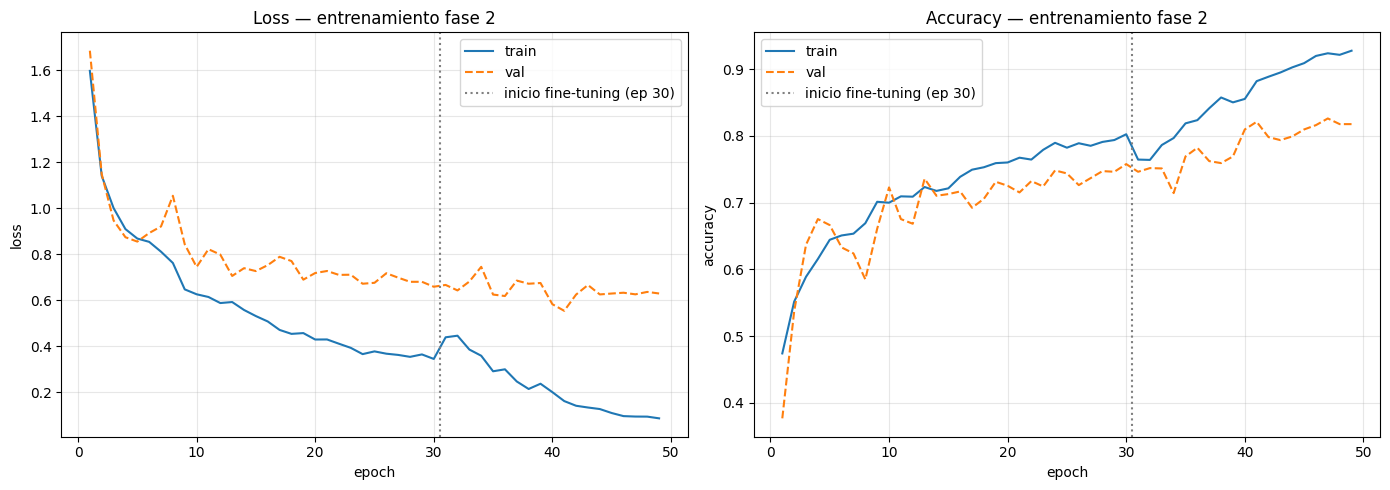

filas del CSV: 2003  (esperado 2003)
NaN en probabilidades: 0
suma softmax por fila en [0.99, 1.01]: True


In [7]:
# Curvas de entrenamiento (train vs val) y chequeo del CSV
hist = pd.read_csv(EXP_DIR / "history.csv")
sep  = len(h1.history["loss"])   # fin del warmup / inicio del fine-tuning
ep   = np.arange(1, len(hist) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (m_tr, m_va, title) in zip(
        axes, [("loss", "val_loss", "Loss"), ("accuracy", "val_accuracy", "Accuracy")]):
    ax.plot(ep, hist[m_tr], label="train")
    ax.plot(ep, hist[m_va], linestyle="--", label="val")
    ax.axvline(sep + 0.5, color="gray", linestyle=":", label=f"inicio fine-tuning (ep {sep})")
    ax.set_title(f"{title} - entrenamiento fase 2")
    ax.set_xlabel("epoch"); ax.set_ylabel(title.lower())
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(EXP_DIR / "training_curves_fase2.png", dpi=120); plt.show()

probs = df_pred[[f"prob_{c}" for c in class_names]].values
print(f"filas del CSV: {len(df_pred)}  (esperado {len(df_test)})")
print(f"NaN en probabilidades: {int(np.isnan(probs).sum())}")
print(f"suma softmax por fila en [0.99, 1.01]: {bool(np.allclose(probs.sum(axis=1), 1.0, atol=1e-2))}")